# Exploratory Data Analysis (EDA) - ISCX Tabular Engine

This notebook serves as the **Research & Validation Phase** for the Tabular Structural Features engine. We explore the ISCX 2016 URL Dataset to understand class distributions, missing values, and feature bounds before feeding them into our 9 baseline models.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('muted')

### 1. Data Ingestion & Target Serialization
The dataset contains a multi-class string column (`URL_Type_obf_Type`). We must map this to a Binary distribution (`1` for Phishing/Malware/Defacement, `0` for Benign).

Original ISCX Shape: (36707, 80)


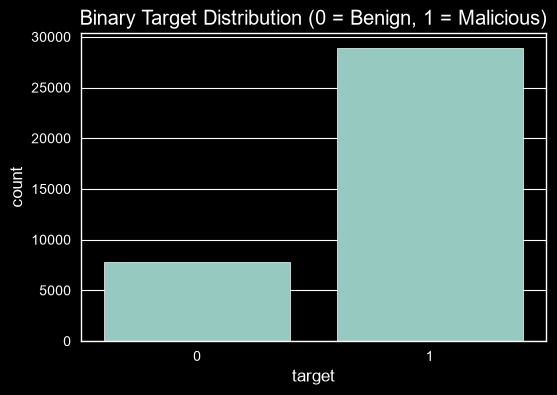

In [9]:
df = pd.read_csv('../data/iscx_phishing/All.csv', low_memory=False)
print(f"Original ISCX Shape: {df.shape}")

target_col = 'URL_Type_obf_Type'
df['target'] = df[target_col].apply(lambda x: 0 if str(x).strip().lower() == 'benign' else 1)

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='target')
plt.title('Binary Target Distribution (0 = Benign, 1 = Malicious)')
plt.show()

### 2. Structural Separation Analysis (KDE Distributions)
Before training, we must verify if structural features actually provide separability. Let's look at `urlLen` (URL Length).

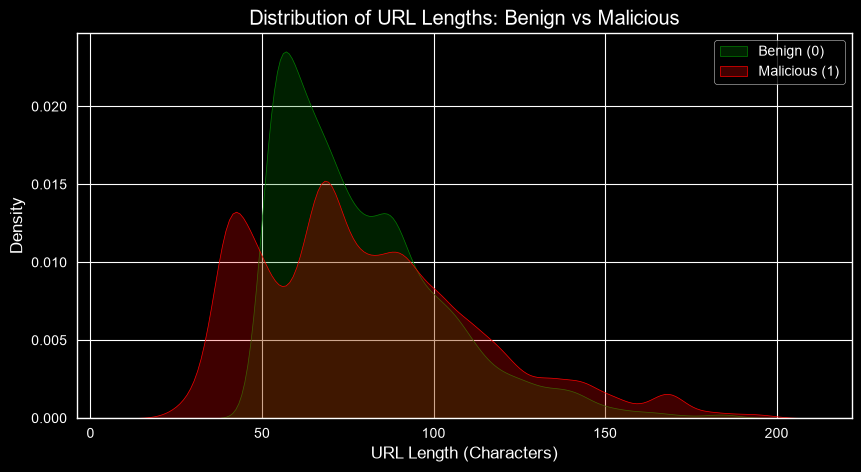

Observation: Malicious URLs have a much wider and longer distribution tail, indicating that phishers use long query strings and subdirectories to obfuscate their payloads.


In [10]:
# Filter outliers for a cleaner visualization (lengths > 200 are rare)
plot_df = df[df['urlLen'] < 200]

plt.figure(figsize=(10, 5))
sns.kdeplot(data=plot_df[plot_df['target'] == 0]['urlLen'], fill=True, color='green', label='Benign (0)')
sns.kdeplot(data=plot_df[plot_df['target'] == 1]['urlLen'], fill=True, color='red', label='Malicious (1)')

plt.title('Distribution of URL Lengths: Benign vs Malicious')
plt.xlabel('URL Length (Characters)')
plt.ylabel('Density')
plt.legend()
plt.show()

print("Observation: Malicious URLs have a much wider and longer distribution tail, indicating that phishers use long query strings and subdirectories to obfuscate their payloads.")

### 3. Isolating High-Impact Indicators
We can also look at discrete indicators, such as the number of dots in a URL or the presence of an executable extension.

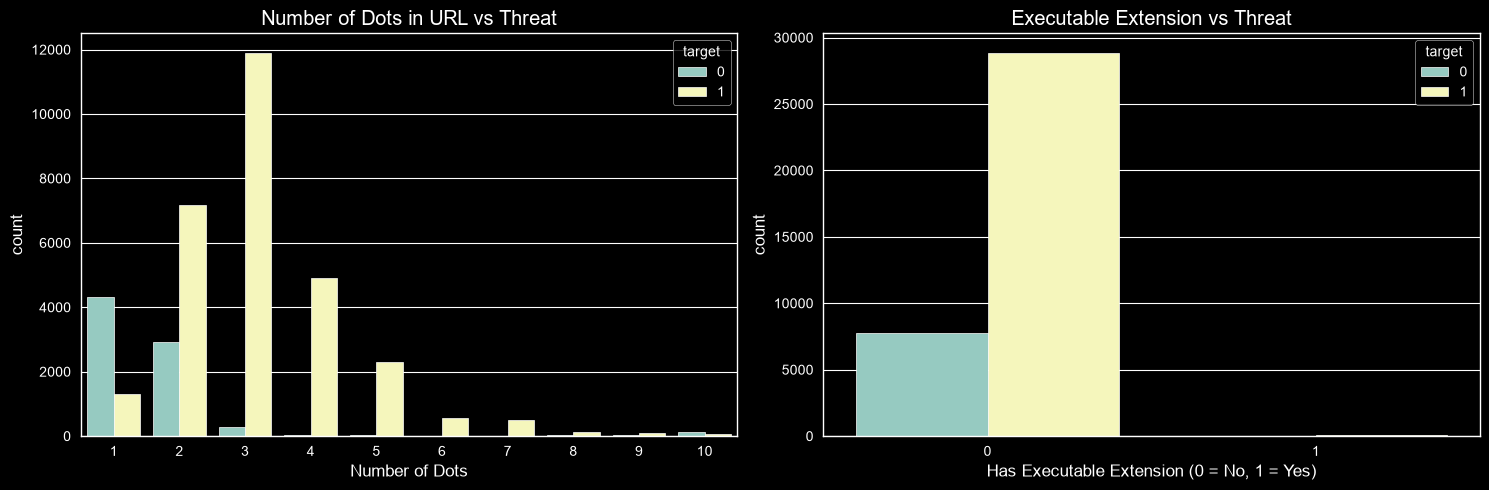

Observation: URLs with highly abnormal dot counts or direct executable extensions are overwhelmingly malicious.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Cap dots at 10 for visualization
df['dots_capped'] = df['NumberofDotsinURL'].apply(lambda x: x if x < 10 else 10)

sns.countplot(data=df, x='dots_capped', hue='target', ax=axes[0])
axes[0].set_title('Number of Dots in URL vs Threat')
axes[0].set_xlabel('Number of Dots')

sns.countplot(data=df, x='executable', hue='target', ax=axes[1])
axes[1].set_title('Executable Extension vs Threat')
axes[1].set_xlabel('Has Executable Extension (0 = No, 1 = Yes)')

plt.tight_layout()
plt.show()

print("Observation: URLs with highly abnormal dot counts or direct executable extensions are overwhelmingly malicious.")

### 4. Correlation Heatmap (Top Predictive Features)
Plotting a 79x79 matrix is visually messy. Instead, we isolate the Top 15 features most highly correlated with the target to ensure our ML models will have strong mathematical signals.

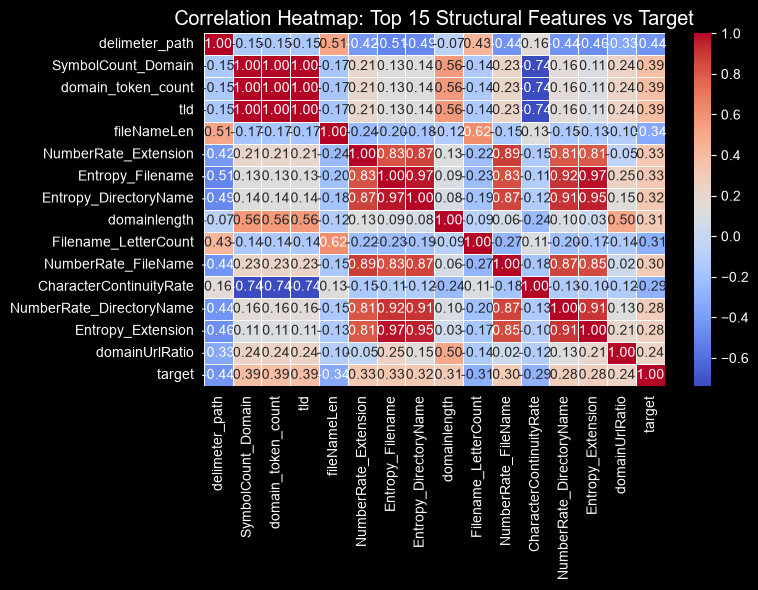

In [12]:
# Isolate numerical columns and scrub infinities for correlation math
num_df = df.select_dtypes(include=[np.number]).replace([np.inf, -np.inf], np.nan).dropna()

# Get the top 15 features correlated with 'target'
correlations = num_df.corr()['target'].abs().sort_values(ascending=False)
top_features = correlations[1:16].index.tolist()  # Skip 'target' itself

plt.figure(figsize=(8, 6))
sns.heatmap(num_df[top_features + ['target']].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap: Top 15 Structural Features vs Target")
plt.tight_layout()
plt.show()

### 5. Feature Filtering & Infinities
The ISCX dataset is prone to divide-by-zero errors resulting in `np.inf`. We must cast these to `NaN` so the `SimpleImputer` can safely transform them to medians in the production pipeline.

In [13]:
X = df.drop(columns=[target_col, 'target'], errors='ignore')
X = X.select_dtypes(include=[np.number])

# Check for Infinities
inf_count = np.isinf(X).values.sum()
print(f"Total Infinity Values Detected: {inf_count}")

# Scrub infinities
X = X.replace([np.inf, -np.inf], np.nan)
print(f"Infinities scrubbed. Matrix ready for SimpleImputer pipeline.")

Total Infinity Values Detected: 10
Infinities scrubbed. Matrix ready for SimpleImputer pipeline.
